# 01 · Seasonal streamflow forecast (Upper Zambezi)

Reproduces the regime forecast of the WRR draft (Section 4.1): the **day of year** is the only predictor, so GPU learns a seasonal exceedance distribution that repeats every year. Evaluated on an independent validation period.

In [2]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from foresight_gpu import GPURegressor
from foresight_gpu.metrics.probabilistic import renard_metrics
from foresight_gpu.utils import plot_timeseries, plot_qq, plot_double_pareto_front

DATA = Path('..') / 'examples' / 'data'

### Load observed discharge and build day-of-year features

In [3]:
flow = pd.read_csv(DATA / 'Qobs.txt', sep='\t', header=0, names=['date', 'Qobs'],
                   index_col=0, parse_dates=True)['Qobs'].dropna()
doy = flow.index.dayofyear.to_numpy(float)
X = np.column_stack([np.sin(2*np.pi*doy/365.25), np.cos(2*np.pi*doy/365.25)])
y = flow.to_numpy(float)
train = flow.index.year < 1997
print('train days', int(train.sum()), '| validation days', int((~train).sum()))

train days 5843 | validation days 5866


### Fit (this takes ~1 minute)

In [4]:
gpu = GPURegressor(metric='mae', population=500, n_iter=100,
                   force_positive=True, random_state=0).fit(X[train], y[train])

### Validate on the held-out years

In [5]:
pv = gpu.predictive_pvalues(X[~train], y[~train])
bands = gpu.predict_quantiles(X[~train])
diag = renard_metrics(pv, bands, gpu.ensemble_.band_probabilities)
print({k: round(v, 3) for k, v in diag.items()})

{'alpha': 0.939, 'xi': 0.988, 'pi': 0.139, 'pi_rel': 0.985, 'sigma': 8.926}


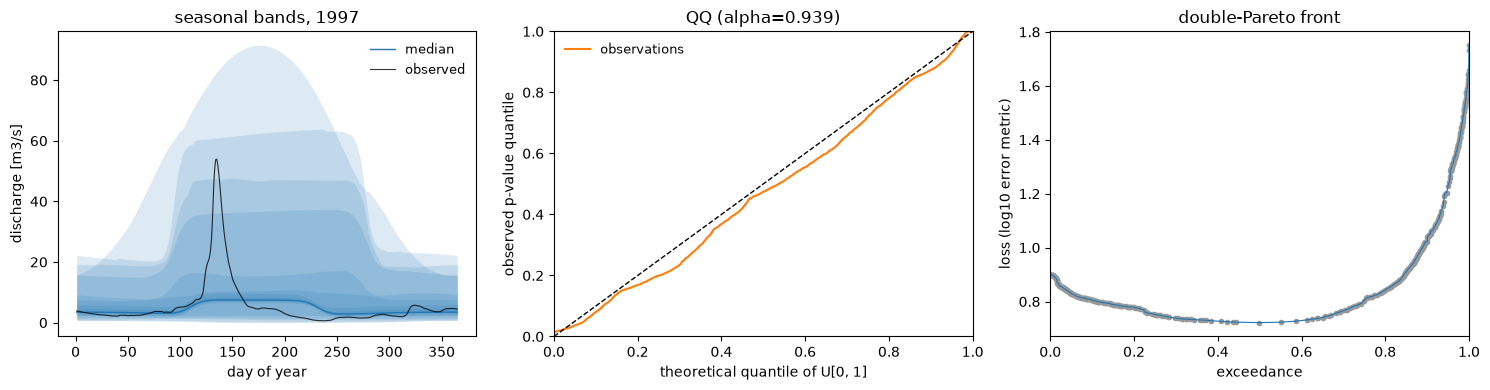

In [6]:
val_index = flow.index[~train]
yr = val_index.year[0]
mask = val_index.year == yr
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
plot_timeseries(bands[mask], gpu.ensemble_.quantiles, observed=y[~train][mask],
                index=val_index[mask].dayofyear, ax=ax[0])
ax[0].set_title(f'seasonal bands, {yr}'); ax[0].set_xlabel('day of year')
ax[0].set_ylabel('discharge [m3/s]')
plot_qq(pv, ax=ax[1]); ax[1].set_title(f"QQ (alpha={diag['alpha']:.3f})")
plot_double_pareto_front(gpu._fit[:, 0], gpu._fit[:, 1], ax=ax[2], max_fronts=6)
ax[2].set_title('double-Pareto front')
fig.tight_layout()

Reliability (alpha, xi) is high and the QQ plot hugs the diagonal, while the seasonal bands are wide — exactly the low-resolution, high-reliability regime forecast the paper describes. Adding past discharge as predictors would sharpen the bands (higher resolution pi).